Connect to dataset on google drive if you want to run notebook on google colab

In [4]:
# Load the Drive helper and mount
from google.colab import drive

# This will prompt for authorization.
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
#import all required libraries and constants
import os
import librosa
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler
import tensorflow.keras.backend as K
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Define paths and parameters
NUM_CLASSES = 2  # Number of classes (bonafide and spoof)
SAMPLE_RATE = 22050  # Sample rate of your audio files
DURATION = 5  # Duration of audio clips in seconds
N_MELS = 128  # Number of Mel frequency bins
max_time_steps = 109  # Define the maximum time steps for your model
N_MFCC = 13  # You can adjust this value based on your needs


This code snippet performs the extraction and preprocessing of audio data for a deepfake detection model using the Mel spectrogram representation.. The process involves loading audio files from both real and fake data stored in 4 separate directories as :

RARV represent real audio real video

RAFV represent real audio fake video

FARV represent fake audio real video

FAFV represent fake audio fake video

then both RARV and RAFV contain real audio,

and both FARV and FAFV contain fake audio.

 For each file, the code extracts Mel spectrograms using the librosa library. These spectrograms are then converted to decibel scale and adjusted to have consistent time steps (width). The processed spectrograms and corresponding labels are stored in separate lists, and these lists are converted into NumPy arrays for further use in the deepfake detection model.

In [ ]:

# Directory paths
real_audio_dir = '/content/drive/MyDrive/RARV_audio'
real_audio_dir_2 = '/content/drive/MyDrive/RAFV_audio'
fake_audio_dir = '/content/drive/MyDrive/FARV_audio'
fake_audio_dir_2 = '/content/drive/MyDrive/FAFV_audio'

# Lists to store features and labels
X = []
Y = []

# Load and preprocess real audio data
for file in os.listdir(real_audio_dir):
    if file.endswith('.flac'):
        audio_path = os.path.join(real_audio_dir, file)
        try:
            # Load audio file using librosa
            audio, _ = librosa.load(audio_path, sr=SAMPLE_RATE, duration=DURATION)

            # Extract Mel spectrogram using librosa
            mel_spectrogram = librosa.feature.melspectrogram(y=audio, sr=SAMPLE_RATE, n_mels=N_MELS)
            mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)

            # Ensure all spectrograms have the same width (time steps)
            if mel_spectrogram.shape[1] < max_time_steps:
                mel_spectrogram = np.pad(mel_spectrogram, ((0, 0), (0, max_time_steps - mel_spectrogram.shape[1])), mode='constant')
            else:
                mel_spectrogram = mel_spectrogram[:, :max_time_steps]


            X.append(mel_spectrogram)
            Y.append(1)
        except FileNotFoundError:
            print(f"File not found: {file}")

# Load and preprocess real audio data
for file in os.listdir(real_audio_dir_2):
    if file.endswith('.flac'):
        audio_path = os.path.join(real_audio_dir_2, file)
        try:
            # Load audio file using librosa
            audio, _ = librosa.load(audio_path, sr=SAMPLE_RATE, duration=DURATION)

            # Extract Mel spectrogram using librosa
            mel_spectrogram = librosa.feature.melspectrogram(y=audio, sr=SAMPLE_RATE, n_mels=N_MELS)
            mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)

            # Ensure all spectrograms have the same width (time steps)
            if mel_spectrogram.shape[1] < max_time_steps:
                mel_spectrogram = np.pad(mel_spectrogram, ((0, 0), (0, max_time_steps - mel_spectrogram.shape[1])), mode='constant')
            else:
                mel_spectrogram = mel_spectrogram[:, :max_time_steps]


            X.append(mel_spectrogram)
            Y.append(1)
        except FileNotFoundError:
            print(f"File not found: {file}")

# Load and preprocess fake audio data
for file in os.listdir(fake_audio_dir):
    if file.endswith('.flac'):
        audio_path = os.path.join(fake_audio_dir, file)
        try:
            # Load audio file using librosa
            audio, _ = librosa.load(audio_path, sr=SAMPLE_RATE, duration=DURATION)

            # Extract Mel spectrogram using librosa
            mel_spectrogram = librosa.feature.melspectrogram(y=audio, sr=SAMPLE_RATE, n_mels=N_MELS)
            mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)

            # Ensure all spectrograms have the same width (time steps)
            if mel_spectrogram.shape[1] < max_time_steps:
                mel_spectrogram = np.pad(mel_spectrogram, ((0, 0), (0, max_time_steps - mel_spectrogram.shape[1])), mode='constant')
            else:
                mel_spectrogram = mel_spectrogram[:, :max_time_steps]


            X.append(mel_spectrogram)
            Y.append(0)
        except FileNotFoundError:
            print(f"File not found: {file}")

# Load and preprocess fake audio data
for file in os.listdir(fake_audio_dir_2):
    if file.endswith('.flac'):
        audio_path = os.path.join(fake_audio_dir_2, file)
        try:
            # Load audio file using librosa
            audio, _ = librosa.load(audio_path, sr=SAMPLE_RATE, duration=DURATION)

            # Extract Mel spectrogram using librosa
            mel_spectrogram = librosa.feature.melspectrogram(y=audio, sr=SAMPLE_RATE, n_mels=N_MELS)
            mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)

            # Ensure all spectrograms have the same width (time steps)
            if mel_spectrogram.shape[1] < max_time_steps:
                mel_spectrogram = np.pad(mel_spectrogram, ((0, 0), (0, max_time_steps - mel_spectrogram.shape[1])), mode='constant')
            else:
                mel_spectrogram = mel_spectrogram[:, :max_time_steps]


            X.append(mel_spectrogram)
            Y.append(0)
        except FileNotFoundError:
            print(f"File not found: {file}")


# Convert lists to numpy arrays
X = np.array(X)
Y = np.array(Y)


In [ ]:
# Save the arrays
np.save('/content/drive/MyDrive/X_melspect.npy', X)
np.save('/content/drive/MyDrive/Y_melspect.npy', Y)

In [5]:
# Load the arrays
X = np.load('/content/drive/MyDrive/X_melspect.npy')
Y = np.load('/content/drive/MyDrive/Y_melspect.npy')

In [6]:
X_train, X_val, y_train, y_val = train_test_split(X, Y, test_size=0.25, random_state=42,stratify=Y)

The next cell begins by defining the input shape based on the number of Mel spectogram features. Afterthat, the CNN model is constructed with convolutional and pooling layers, followed by fully connected layers with dropout for regularization.  The output layer has a sigmoid activation function, indicating binary classification. Additionally, a learning rate scheduler is defined, and the model is compiled using the Adam optimizer with a binary crossentropy loss function and accuracy metric.

In [7]:

# Assuming input_shape is defined correctly
input_shape = (N_MELS, X_train.shape[2], 1)

# Define CNN model architecture
model_input = Input(shape=input_shape)
x = Conv2D(64, kernel_size=(3, 3), activation='relu')(model_input)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Conv2D(32, kernel_size=(3, 3), activation='relu')(model_input)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
model_output = Dense(1, activation='sigmoid')(x)
# Create and compile the model
model = Model(inputs=model_input, outputs=model_output)
# Function to schedule the learning rate
def lr_schedule(epoch):
    initial_lr = 0.01  # Set your initial learning rate here
    decay_factor = 0.9  # Set the decay factor

    lr = initial_lr * decay_factor ** epoch
    return lr

# Create the learning rate scheduler callback
lr_scheduler = LearningRateScheduler(lr_schedule)
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

In [8]:
# Train the Model
history = model.fit(X_train, y_train, batch_size=32, epochs=10, validation_data=(X_val, y_val), callbacks=[lr_scheduler] )

Epoch 1/10
405/405 [==============================] - 12s 16ms/step - loss: 20.7811 - accuracy: 0.5878 - val_loss: 0.4159 - val_accuracy: 0.8049 - lr: 0.0100
Epoch 2/10
405/405 [==============================] - 5s 13ms/step - loss: 0.2780 - accuracy: 0.8850 - val_loss: 0.1228 - val_accuracy: 0.9539 - lr: 0.0090
Epoch 3/10
405/405 [==============================] - 6s 14ms/step - loss: 0.1137 - accuracy: 0.9625 - val_loss: 0.0690 - val_accuracy: 0.9796 - lr: 0.0081
Epoch 4/10
405/405 [==============================] - 5s 13ms/step - loss: 0.0820 - accuracy: 0.9745 - val_loss: 0.0562 - val_accuracy: 0.9829 - lr: 0.0073
Epoch 5/10
405/405 [==============================] - 5s 13ms/step - loss: 0.0624 - accuracy: 0.9793 - val_loss: 0.0397 - val_accuracy: 0.9882 - lr: 0.0066
Epoch 6/10
405/405 [==============================] - 6s 14ms/step - loss: 0.0469 - accuracy: 0.9869 - val_loss: 0.0348 - val_accuracy: 0.9907 - lr: 0.0059
Epoch 7/10
405/405 [==============================] - 5s 12ms/

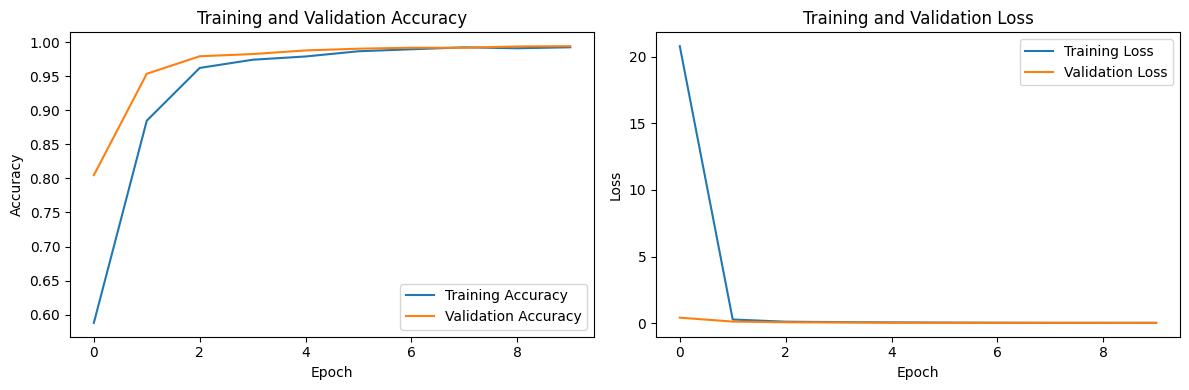

In [9]:

# Plot training and validation accuracy
plt.figure(figsize=(12, 4))

# Plot training accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# Plot training loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.tight_layout()

In [ ]:

# Directory paths
real_audio_dir = '/content/drive/MyDrive/RARV_audio_test'
real_audio_dir_2 = '/content/drive/MyDrive/RAFV_audio_test'
fake_audio_dir = '/content/drive/MyDrive/FARV_audio_test'
fake_audio_dir_2 = '/content/drive/MyDrive/FAFV_audio_test'

# Lists to store features and labels
X_test = []
Y_test = []

# Load and preprocess real audio data
for file in os.listdir(real_audio_dir):
    if file.endswith('.flac'):
        audio_path = os.path.join(real_audio_dir, file)
        try:
            # Load audio file using librosa
            audio, _ = librosa.load(audio_path, sr=SAMPLE_RATE, duration=DURATION)

            # Extract Mel spectrogram using librosa
            mel_spectrogram = librosa.feature.melspectrogram(y=audio, sr=SAMPLE_RATE, n_mels=N_MELS)
            mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)

            # Ensure all spectrograms have the same width (time steps)
            if mel_spectrogram.shape[1] < max_time_steps:
                mel_spectrogram = np.pad(mel_spectrogram, ((0, 0), (0, max_time_steps - mel_spectrogram.shape[1])), mode='constant')
            else:
                mel_spectrogram = mel_spectrogram[:, :max_time_steps]


            X_test.append(mel_spectrogram)
            Y_test.append(1)
        except FileNotFoundError:
            print(f"File not found: {file}")

# Load and preprocess real audio data
for file in os.listdir(real_audio_dir_2):
    if file.endswith('.flac'):
        audio_path = os.path.join(real_audio_dir_2, file)
        try:
            # Load audio file using librosa
            audio, _ = librosa.load(audio_path, sr=SAMPLE_RATE, duration=DURATION)

            # Extract Mel spectrogram using librosa
            mel_spectrogram = librosa.feature.melspectrogram(y=audio, sr=SAMPLE_RATE, n_mels=N_MELS)
            mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)

            # Ensure all spectrograms have the same width (time steps)
            if mel_spectrogram.shape[1] < max_time_steps:
                mel_spectrogram = np.pad(mel_spectrogram, ((0, 0), (0, max_time_steps - mel_spectrogram.shape[1])), mode='constant')
            else:
                mel_spectrogram = mel_spectrogram[:, :max_time_steps]


            X_test.append(mel_spectrogram)
            Y_test.append(1)
        except FileNotFoundError:
            print(f"File not found: {file}")

# Load and preprocess fake audio data
for file in os.listdir(fake_audio_dir):
    if file.endswith('.flac'):
        audio_path = os.path.join(fake_audio_dir, file)
        try:
            # Load audio file using librosa
            audio, _ = librosa.load(audio_path, sr=SAMPLE_RATE, duration=DURATION)

            # Extract Mel spectrogram using librosa
            mel_spectrogram = librosa.feature.melspectrogram(y=audio, sr=SAMPLE_RATE, n_mels=N_MELS)
            mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)

            # Ensure all spectrograms have the same width (time steps)
            if mel_spectrogram.shape[1] < max_time_steps:
                mel_spectrogram = np.pad(mel_spectrogram, ((0, 0), (0, max_time_steps - mel_spectrogram.shape[1])), mode='constant')
            else:
                mel_spectrogram = mel_spectrogram[:, :max_time_steps]


            X_test.append(mel_spectrogram)
            Y_test.append(0)
        except FileNotFoundError:
            print(f"File not found: {file}")

# Load and preprocess fake audio data
for file in os.listdir(fake_audio_dir_2):
    if file.endswith('.flac'):
        audio_path = os.path.join(fake_audio_dir_2, file)
        try:
            # Load audio file using librosa
            audio, _ = librosa.load(audio_path, sr=SAMPLE_RATE, duration=DURATION)

            # Extract Mel spectrogram using librosa
            mel_spectrogram = librosa.feature.melspectrogram(y=audio, sr=SAMPLE_RATE, n_mels=N_MELS)
            mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)

            # Ensure all spectrograms have the same width (time steps)
            if mel_spectrogram.shape[1] < max_time_steps:
                mel_spectrogram = np.pad(mel_spectrogram, ((0, 0), (0, max_time_steps - mel_spectrogram.shape[1])), mode='constant')
            else:
                mel_spectrogram = mel_spectrogram[:, :max_time_steps]


            X_test.append(mel_spectrogram)
            Y_test.append(0)
        except FileNotFoundError:
            print(f"File not found: {file}")


# Convert lists to numpy arrays
X_test = np.array(X_test)
Y_test = np.array(Y_test)


In [ ]:
# Save the arrays
np.save('/content/drive/MyDrive/X_melspect_test.npy', X_test)
np.save('/content/drive/MyDrive/Y_melspect_test.npy', Y)

In [ ]:
# Load the arrays
X_test = np.load('/content/drive/MyDrive/X_melspect_test.npy')
Y_test = np.load('/content/drive/MyDrive/Y_melspect_test.npy')

In [ ]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test, Y_test)
print(f'Test accuracy: {test_acc}')

540/540 [==============================] - 4s 8ms/step - loss: 0.0151 - accuracy: 0.9992
Test accuracy: 0.9991888403892517


In [ ]:
# Save the entire model to a file after training
model.save("/content/drive/MyDrive/audio_spectogram_model.h5")

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
# Load the model
model = load_model("/content/drive/MyDrive/audio_spectogram_model.h5")


In [ ]:
# Evaluate the model on the test set
Y_pred = model.predict(X_test)


540/540 [==============================] - 6s 6ms/step
Test Preditions: [[9.9891508e-01]
 [9.9125439e-01]
 [9.1050911e-01]
 ...
 [1.7817948e-08]
 [9.5336341e-05]
 [1.2741681e-07]]


In [ ]:
import seaborn as sns

# Apply a threshold to convert probabilities into binary predictions
threshold = 0.5
y_pred = (Y_pred > threshold).astype(int)


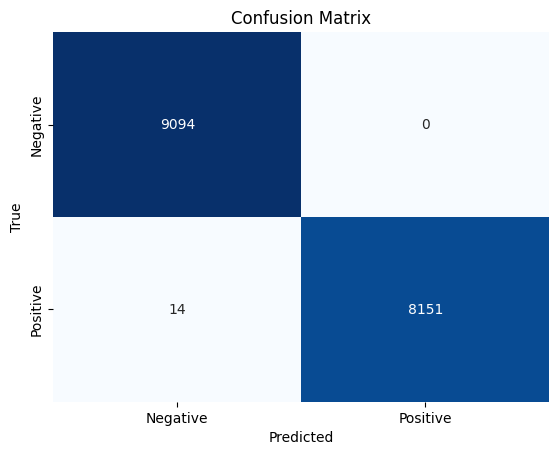

In [ ]:

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
# Create the confusion matrix
conf_matrix = confusion_matrix(Y_test, y_pred)

# Plot the confusion matrix using seaborn
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

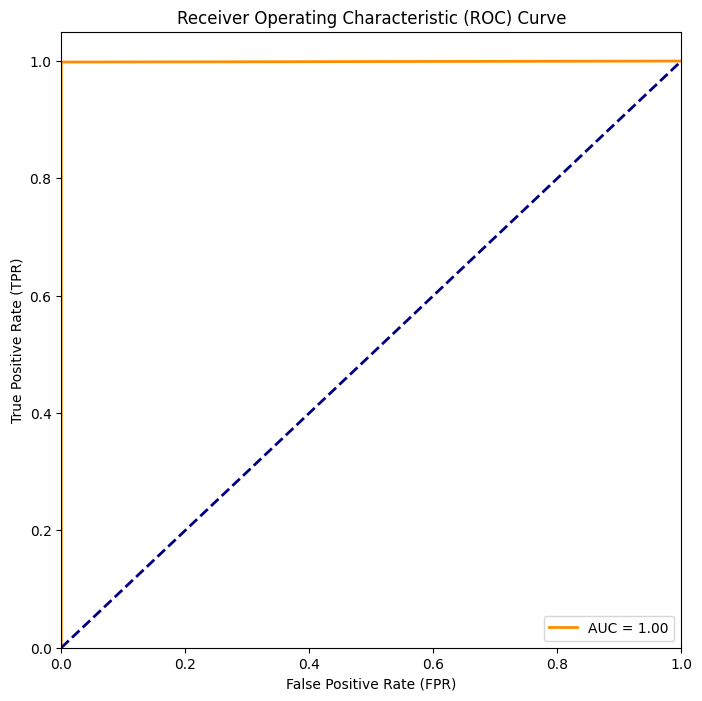

In [ ]:
from sklearn.metrics import roc_curve, auc
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(Y_test, y_pred)

# Compute area under the curve (AUC)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Assuming y_true contains the true labels and y_pred contains the predicted labels

# Calculate precision, recall, and F1-score
precision = precision_score(Y_test, y_pred)
recall = recall_score(Y_test, y_pred)
f1 = f1_score(Y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)


Precision: 1.0
Recall: 0.9982853643600735
F1-score: 0.9991419465555283


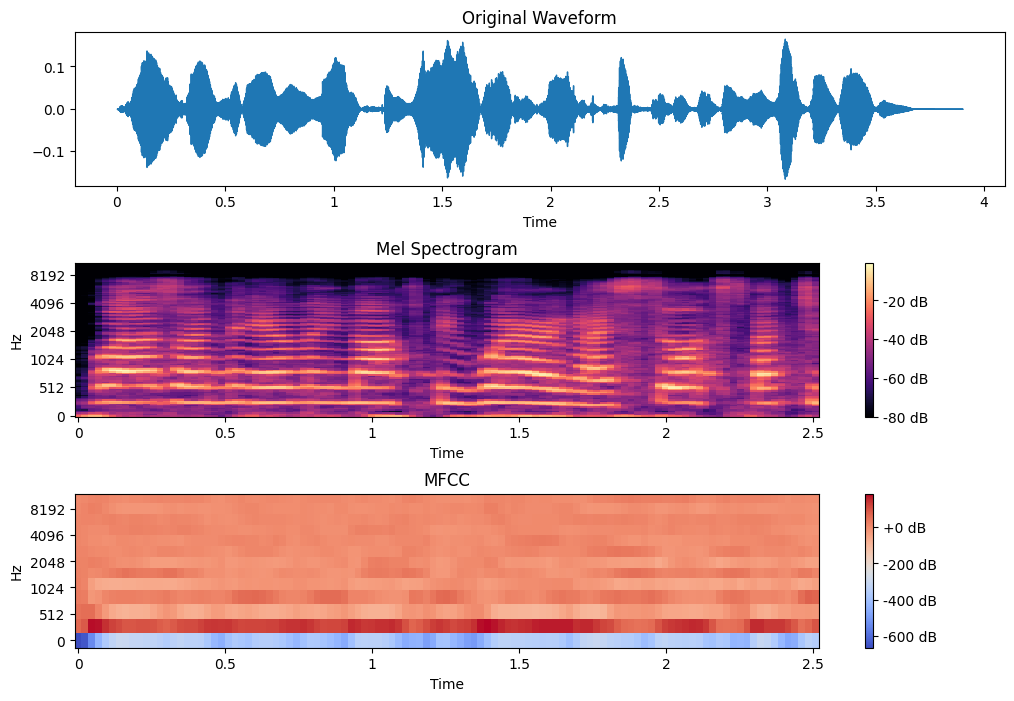

In [10]:
# example for an original audio with its mel-spectogram and MFCC representations

import os
import librosa.display
import matplotlib.pyplot as plt

# Function to load and preprocess audio data
def load_and_preprocess_audio(audio_path):
    try:
        # Load audio file using librosa
        audio, _ = librosa.load(audio_path, sr=SAMPLE_RATE, duration=DURATION)

        # Extract Mel spectrogram using librosa
        mel_spectrogram = librosa.feature.melspectrogram(y=audio, sr=SAMPLE_RATE, n_mels=N_MELS)
        mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)

        # Extract MFCC features using custom function
        mfcc_features = librosa.feature.mfcc(y=audio, sr=SAMPLE_RATE, n_mfcc=13)

        # Ensure all spectrograms have the same width (time steps)
        if mel_spectrogram.shape[1] < max_time_steps:
            mel_spectrogram = np.pad(mel_spectrogram, ((0, 0), (0, max_time_steps - mel_spectrogram.shape[1])), mode='constant')
        else:
            mel_spectrogram = mel_spectrogram[:, :max_time_steps]

        # Ensure all MFCC features have the same width (time steps)
        if mfcc_features.shape[1] < max_time_steps:
            mfcc_features = np.pad(mfcc_features, ((0, 0), (0, max_time_steps - mfcc_features.shape[1])), mode='constant')
        else:
            mfcc_features = mfcc_features[:, :max_time_steps]

        return audio, mel_spectrogram, mfcc_features

    except FileNotFoundError:
        print(f"File not found: {audio_path}")
        return None, None

# Function to plot original waveform and mel-spectrogram
def plot_audio_and_mel_spectrogram(audio, mel_spectrogram, mfcc):
    plt.figure(figsize=(12, 8))

    # Plot original waveform
    plt.subplot(3, 1, 1)
    librosa.display.waveshow(audio, sr=SAMPLE_RATE)
    plt.title('Original Waveform')

    # Plot mel-spectrogram
    plt.subplot(3, 1, 2)
    librosa.display.specshow(mel_spectrogram, sr=SAMPLE_RATE, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Mel Spectrogram')

    # Plot mel-spectrogram
    plt.subplot(3, 1, 3)
    librosa.display.specshow(mfcc, sr=SAMPLE_RATE, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title('MFCC')

    # Adjust the space between subplots
    plt.subplots_adjust(hspace=0.5)

    plt.show()


audio, mel_spectrogram, mfcc = load_and_preprocess_audio('/content/drive/MyDrive/FAFV_audio_test/00001_id00071_wavtolip.flac')
plot_audio_and_mel_spectrogram(audio, mel_spectrogram, mfcc)
